In [3]:
import torch
from torchvision import datasets, transforms

transform = transforms.ToTensor()

dataset = datasets.VOCDetection(
    root='./data',
    year='2012',
    image_set='train',
    download=True,
    transform=transform
)

print("Размер датасета:", len(dataset))

100%|██████████| 2.00G/2.00G [25:58<00:00, 1.28MB/s]  


Размер датасета: 5717


In [6]:
img, target = dataset[0]

print(type(target))
print(target.keys())

<class 'dict'>
dict_keys(['annotation'])


In [7]:
import pprint
pprint.pprint(target)

{'annotation': {'filename': '2008_000008.jpg',
                'folder': 'VOC2012',
                'object': [{'bndbox': {'xmax': '471',
                                       'xmin': '53',
                                       'ymax': '420',
                                       'ymin': '87'},
                            'difficult': '0',
                            'name': 'horse',
                            'occluded': '1',
                            'pose': 'Left',
                            'truncated': '0'},
                           {'bndbox': {'xmax': '289',
                                       'xmin': '158',
                                       'ymax': '167',
                                       'ymin': '44'},
                            'difficult': '0',
                            'name': 'person',
                            'occluded': '0',
                            'pose': 'Unspecified',
                            'truncated': '1'}],
                'segme

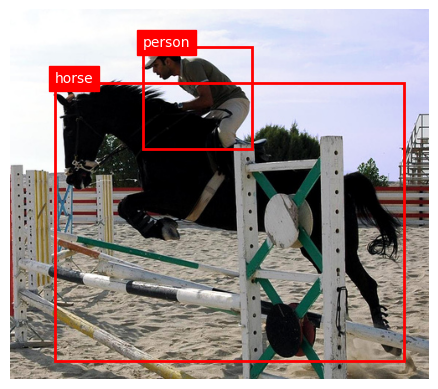

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_image_with_boxes(dataset, idx):
    img, target = dataset[idx]

    fig, ax = plt.subplots(1)
    ax.imshow(img.permute(1,2,0))

    objects = target['annotation']['object']

    # если объект один → приводим к списку
    if not isinstance(objects, list):
        objects = [objects]

    for obj in objects:
        bbox = obj['bndbox']

        xmin = int(bbox['xmin'])
        ymin = int(bbox['ymin'])
        xmax = int(bbox['xmax'])
        ymax = int(bbox['ymax'])

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor='r',
            facecolor='none'
        )
        ax.add_patch(rect)

        ax.text(xmin, ymin, obj['name'], color='white', backgroundcolor='red')

    plt.axis('off')
    plt.show()

show_image_with_boxes(dataset, 0)

In [11]:
import requests

def get_watermarked_bboxes(bboxes, url="http://localhost:8080/process-bboxes"):
    response = requests.post(url, json=bboxes)
    response.raise_for_status()
    return response.json()

In [12]:
def extract_bboxes(target):
    objects = target['annotation']['object']

    if not isinstance(objects, list):
        objects = [objects]

    bboxes = []
    for obj in objects:
        bbox = obj['bndbox']
        bboxes.append([
            float(bbox['xmin']),
            float(bbox['ymin']),
            float(bbox['xmax']),
            float(bbox['ymax'])
        ])

    return bboxes

In [13]:
img, target = dataset[0]

bboxes = extract_bboxes(target)

# 👉 вызываем сервис
watermarked_bboxes = get_watermarked_bboxes(bboxes)

print("Original:", bboxes)
print("Watermarked:", watermarked_bboxes)

Original: [[53.0, 87.0, 471.0, 420.0], [158.0, 44.0, 289.0, 167.0]]
Watermarked: [[52.95177427504882, 88.76004808125703, 470.9517742750488, 421.760048081257], [158.97021844247246, 43.541315258114935, 289.97021844247246, 166.54131525811493]]


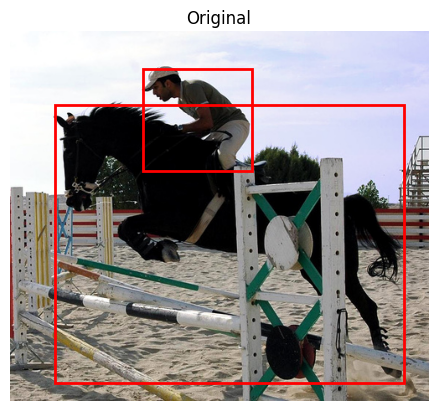

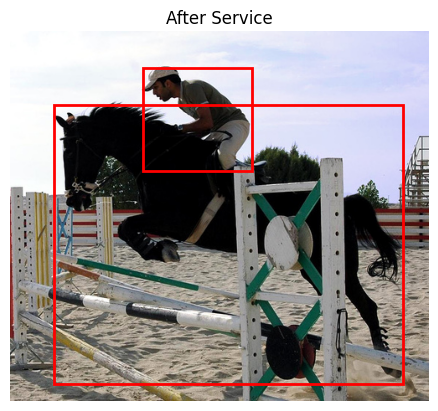

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_boxes(image, bboxes, title=""):
    fig, ax = plt.subplots(1)
    ax.imshow(image.permute(1,2,0))

    for box in bboxes:
        x1, y1, x2, y2 = map(int, box)

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    plt.title(title)
    plt.axis('off')
    plt.show()


show_boxes(img, bboxes, "Original")
show_boxes(img, watermarked_bboxes, "After Service")

In [ ]:
all_data = []

for i in range(len(dataset)):
    img, target = dataset[i]

    bboxes = extract_bboxes(target)
    new_bboxes = get_watermarked_bboxes(bboxes)

    all_data.append({
        "image": img,
        "bboxes": new_bboxes
    })

    if i % 100 == 0:
        print(f"Processed {i}")

Processed 0
Processed 100
Processed 200
Processed 300
Processed 400
Processed 500
Processed 600
Processed 700
Processed 800
Processed 900
Processed 1000
Processed 1100
Processed 1200
Processed 1300
Processed 1400
Processed 1500
Processed 1600
Processed 1700
Processed 1800
Processed 1900
Processed 2000
Processed 2100
Processed 2200
Processed 2300
Processed 2400
Processed 2500
Processed 2600
Processed 2700
Processed 2800
Processed 2900
Processed 3000
Processed 3100
Processed 3200
Processed 3300
Processed 3400
Processed 3500
Processed 3600
Processed 3700
Processed 3800
Processed 3900
Processed 4000
Processed 4100
Processed 4200
Processed 4300
Processed 4400
Processed 4500
Processed 4600
Processed 4700
Processed 4800
Processed 4900
Processed 5000
Processed 5100
Processed 5200
Processed 5300
Processed 5400
Processed 5500
Processed 5600
Processed 5700


In [1]:
import torch


In [ ]:

torch.save(all_data, "watermarked_dataset.pt")

In [ ]:
data = torch.load("watermarked_dataset.pt")

In [ ]:
import random
all_data = data
# перемешиваем
random.shuffle(all_data)

# делим
split_idx = int(0.8 * len(all_data))

train_data = all_data[:split_idx]
test_data = all_data[split_idx:]

print("Train:", len(train_data))
print("Test:", len(test_data))

Train: 4573
Test: 1144


In [ ]:
from torch.utils.data import Dataset
import torch

class DetectionDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        img = item["image"]
        bboxes = item["bboxes"]

        boxes = torch.tensor(bboxes, dtype=torch.float32)

        # пока один класс (object)
        labels = torch.ones((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return img, target

In [ ]:
train_dataset = DetectionDataset(train_data)
test_dataset = DetectionDataset(test_data)

In [ ]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
import torchvision

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

num_classes = 2  # фон + 1 класс

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

C:\Users\dstep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\dstep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


: 

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        print(f"Epoch {epoch}, batch {i}")
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    print(f"Epoch {epoch}: Loss = {total_loss:.4f}")